### Analyze calls (spont, playback) jointly

In [6]:
import sys, importlib

sys.path.append('./../') # rel. dir. to find toolbox 
from npxtoolbox import unpack, plot, wrangle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import seaborn as sns

plt.style.use('default')

formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((3, 3))

# for plotting
treatments = ['saline','muscimol']
treatment_map = {'saline': plt.cm.viridis(np.linspace(0.4,0.6,1)), 
                 'muscimol': plt.cm.magma(np.linspace(0.4,0.6,1))}
metric_lab_map = {'duration': 'dur [ms]',
                  'rms':'norm. rms [$V^{2}$]', 
                  'spec_peak': 'peak freq. [kHz]',
                  'centroid_med': 'median centroid [kHz]',
                  }
cluster_map = ['#8DA6A6','#D6CFB6','#C19A62','#E58A6A','#A93B31']
conditions_map = {'echo_seq': '#8CBEB2',                        
                    'distress_seq': '#F3B562',
                    'isolation_1':'#F06060'}  

In [3]:
df_analysis = pd.read_csv('./../../data/vocal_data/combined_analysis_dataset.csv')

In [4]:

df_analysis['treatment'] = pd.Categorical(df_analysis['treatment'], categories=['saline', 'muscimol'], ordered=True)
df_analysis['call_type'] = pd.Categorical(df_analysis['call_type'], categories=['comm', 'echo'], ordered=True)
df_analysis['sess_type'] = pd.Categorical(df_analysis['sess_type'], categories=['spontaneous', 'playback'], ordered=True)

In [ ]:
# cache_dir = './../../../Npv1_data/Npv1_cachedata'
results_dir = './../../../results/voc_combined'
hash = '24072026_40_0.4'
save_prefix = results_dir+'/spontaneous_playback-'+hash+'-'
manual_lab = '-manuallabels_samp'

In [6]:
dur_quant_bins = [0.001,0.1,0.25,0.5,0.75,0.9,0.99]
dur_quants = np.quantile(df_analysis['duration']*1000, dur_quant_bins)
dur_quantification = list(zip(dur_quant_bins, np.round(dur_quants,3)))
print((np.min(df_analysis['duration']*1000)),(np.max(df_analysis['duration']*1000)))
dur_quantification


0.12239583332979999 17.955729166658298


[(0.001, 0.289),
 (0.1, 0.414),
 (0.25, 0.581),
 (0.5, 1.039),
 (0.75, 2.039),
 (0.9, 3.956),
 (0.99, 10.414)]

#### Visualize UMAP


In [30]:
save_prefix = results_dir+'/combined/spontaneous_playback-'+hash+'-'


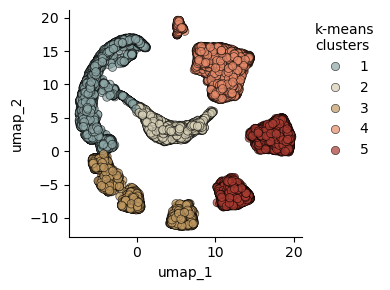

In [31]:
# clusters 
fig, ax = plt.subplots(figsize=(4,3))
sns.scatterplot(df_analysis, x='umap_1', y='umap_2',                 
                hue='k_labels', palette=cluster_map,
                edgecolor='k',
                alpha=0.7,
                ax=ax)
ax.spines[['right','top']].set_visible(False)
ax.legend(loc="upper left", bbox_to_anchor=(1,1), frameon=False, title='k-means\nclusters')
fig.tight_layout()

# fig.savefig(save_prefix + 'umap_k'+manual_lab+'.png',
#             transparent=True, bbox_inches='tight')
for ext in ['png','pdf']:
    fig.savefig(save_prefix + 'umap_k'+manual_lab+'.'+ext, 
                bbox_inches='tight', transparent=True, dpi=200)


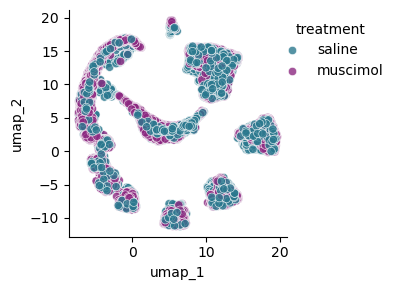

In [32]:
# treatments
fig, ax = plt.subplots(figsize=(4,3))
sns.scatterplot(df_analysis, x='umap_1', y='umap_2',                 
                hue='treatment', palette=treatment_map,
                edgecolor='w',
                alpha=0.8,
                ax=ax)
ax.spines[['right','top']].set_visible(False)
ax.legend(loc="upper left", bbox_to_anchor=(0.9,1), frameon=False, title='treatment')
fig.tight_layout()
# fig.savefig(save_prefix + 'umap_treatment'+manual_lab+'.png',
#                         transparent=True, bbox_inches='tight')
for ext in ['png','pdf']:
    fig.savefig(save_prefix + 'umap_treatment'+manual_lab+'.'+ext, 
                bbox_inches='tight', transparent=True, dpi=200)

/tmp/ipykernel_1805777/2892933396.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  curr_ns = curr_plt.groupby(['treatment'], as_index=False).size()


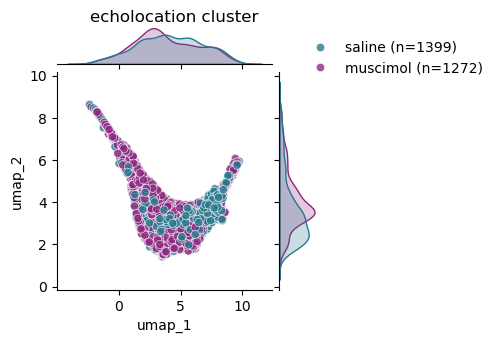

In [11]:
# marginals/cluster zoom
curr_plt = df_analysis.loc[df_analysis['call_type']=='echo']
curr_ns = curr_plt.groupby(['treatment'], as_index=False).size()
treatment_counts = dict(zip(curr_ns['treatment'], curr_ns['size']))

g = sns.JointGrid(curr_plt, x='umap_1', y='umap_2')
g.plot_marginals(
    # sns.histplot, stat="count", element='step',
    sns.kdeplot, fill=True, common_norm=False,
    data=curr_plt,
    hue='treatment', palette=treatment_map)
g.plot_joint(
    sns.scatterplot, 
    # sns.kdeplot, fill=True, levels=15, # thresh=0, cmap='turbo',
    data=curr_plt,             
    hue='treatment',palette=treatment_map,
    alpha=0.8,
    )
# Update legend with counts
handles, labels = g.ax_joint.get_legend_handles_labels()
new_labels = [f"{label} (n={treatment_counts[label]})" for label in labels]
g.ax_joint.legend(handles, new_labels, loc="upper left", bbox_to_anchor=(1.1,1.2), frameon=False)
g.figure.suptitle('echolocation cluster',y=1.03)

g.figure.set_size_inches(3, 3)  
g.savefig(save_prefix + 'umap_call_type_zoom_treatment'+manual_lab+'.png',
                      transparent=True, bbox_inches='tight', dpi=300)

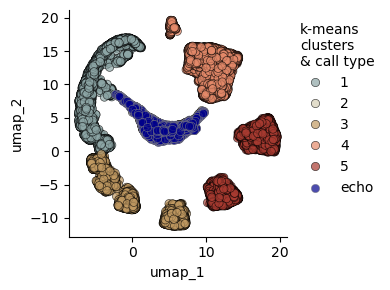

In [33]:
# call type
fig, ax = plt.subplots(figsize=(4,3))
sns.scatterplot(df_analysis, x='umap_1', y='umap_2',                 
                hue='k_labels', palette=cluster_map,
                edgecolor='k',
                alpha=0.7,
                ax=ax)

sns.scatterplot(df_analysis.loc[df_analysis['call_type']=='echo'], x='umap_1', y='umap_2',                 
                color='darkblue', label='echo',
                edgecolor='gray',
                alpha=0.7,
                ax=ax)

ax.spines[['right','top']].set_visible(False)
ax.legend(loc="upper left", bbox_to_anchor=(1,1), frameon=False, title='k-means\nclusters\n& call type')
fig.tight_layout()
# fig.savefig(save_prefix+'umap_call_type'+manual_lab+'.png',
#             transparent=True, bbox_inches='tight')
for ext in ['png','pdf']:
    fig.savefig(save_prefix+'umap_call_type'+manual_lab+'.'+ext, 
                bbox_inches='tight', transparent=True, dpi=200)

##### Duration axis

In [35]:
results_dir
save_prefix = 'spontaneous_playback-'+hash+'-'
save_prefix

'spontaneous_playback-24072026_40_0.4-'

(<Figure size 600x320 with 2 Axes>,
 array([<Axes: xlabel='umap_1', ylabel='umap_2'>,
        <Axes: xlabel='dur [ms]\n(bin upper bound)', ylabel='count'>],
       dtype=object))

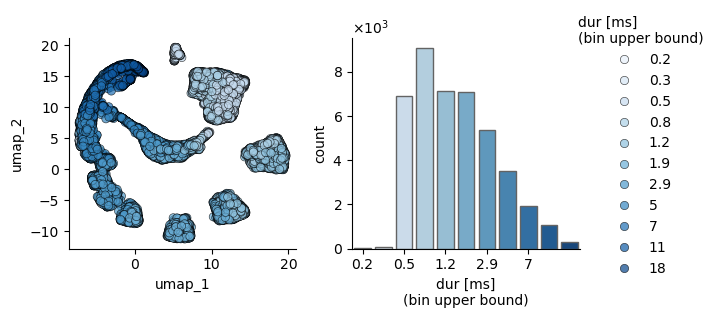

In [37]:
metric = 'duration'
df_analysis = wrangle.bin_col_values(
    df_analysis, colname='duration',
    n_bins=12, log=True, scale=1000, label_decimals=1, int_label_threshold=4)

plot.scatter_umap_metric(
    df_analysis,
    metric=metric,
    metric_lab=metric_lab_map[metric], 
    y_formatter=formatter,
    proj='umap',
    palette='Blues',
    savedir=results_dir+'/combined/',
    filename=save_prefix+'umap_'+metric+'_bins'+manual_lab+'.pdf',
)

##### Energy axis

(<Figure size 600x320 with 2 Axes>,
 array([<Axes: xlabel='umap_1', ylabel='umap_2'>,
        <Axes: xlabel='norm. rms [$V^{2}$] $\\times 10^{-2}$\n(bin upper bound)', ylabel='count'>],
       dtype=object))

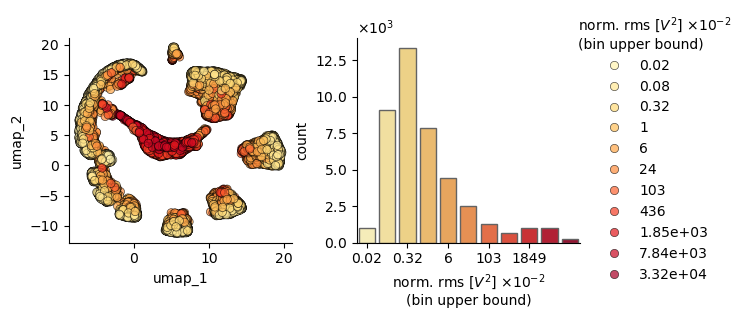

In [39]:
importlib.reload(plot)
# formatter = formatter.set_powerlimits((3, 3))

metric = 'rms'
df_analysis = wrangle.bin_col_values(
    df_analysis, colname='rms',
    n_bins=12, log=True, scale=1e-2, label_decimals=2, int_label_threshold=1,
    )
plot.scatter_umap_metric(
    df_analysis,
    metric=metric,
    metric_lab=metric_lab_map[metric],
    x_scale_label='$\\times 10^{-2}$',
    legend_scale_label='$\\times 10^{-2}$',
    legend_num_format='{:,.3g}',
    y_formatter=formatter,
    proj='umap',
    palette='YlOrRd',
    savedir=results_dir+'/combined/',
    filename=save_prefix+'umap_'+metric+'_bins'+manual_lab+'.png',
)

##### Frequency axis

In [ ]:
metric = 'spec_peak'
for metric in ['spec_peak','centroid_med']:
    metric_lab = metric_lab_map[metric]

    df_analysis = wrangle.bin_col_values(
        df_analysis, colname=metric,
        n_bins=12, log=True, scale=1e-3, int_label_threshold=0)

    plot.scatter_umap_metric(
        df_analysis,
        metric=metric,
        metric_lab=metric_lab_map[metric],
        y_formatter=formatter,
        proj='umap',
        countplot_hue=False,
        palette='YlGnBu',
        savedir=results_dir+'/combined/',
        filename=save_prefix+'umap_'+metric+'_bins'+manual_lab+'.png',
    )

#### Call properties by cluster

###### Call count (treatment)

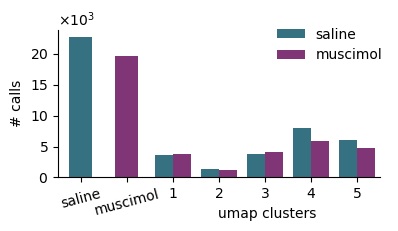

In [42]:
# counts
fig, ax = plt.subplots(figsize=(4,2.5))
sns.countplot(df_analysis, x='treatment',
            hue='treatment', palette=treatment_map,
            width=0.5,
            ax=ax, 
            )
sns.countplot(df_analysis, x='k_labels',
            hue='treatment', palette=treatment_map,
            dodge=True,
            ax=ax
            )

for label in ax.get_xticklabels()[:2]:   # first two ticks only
    label.set_rotation(15)

ax.set_xlabel('umap clusters')
ax.xaxis.set_label_coords(0.65, -0.2)
ax.yaxis.set_major_formatter(formatter)
ax.set_ylabel('# calls')

ax.spines[['right','top']].set_visible(False)

handles, labels = ax.get_legend_handles_labels()
ax.legend_.remove()
fig.legend(handles[:2], labels[:2], loc='right', bbox_to_anchor=(1,0.8), frameon=False)
fig.tight_layout()
# fig.savefig(results_dir+'/combined/'+save_prefix+'counts_treat_cluster'+manual_lab+'_sample.png',transparent=True, bbox_inches='tight')
for ext in ['png','pdf']:
    fig.savefig(results_dir+'/combined/'+save_prefix+'counts_treat_cluster'+manual_lab+'.'+ext, 
                bbox_inches='tight', transparent=True, dpi=200)

##### Call densities by cluster by metrics

In [23]:
cluster_mean_dur = df_analysis.groupby(['k_labels'], observed=True)['duration'].agg(['mean','count'])
cluster_mean_dur['k_labels_order'] = pd.Series(np.argsort(np.argsort(cluster_mean_dur['mean'])))
cluster_mean_dur


,mean,count,k_labels_order
k_labels,,,
1,0.005198,7347,4
2,0.001747,2488,2
3,0.001884,7941,3
4,0.000499,13819,0
5,0.000972,10828,1


In [24]:
cluster_treat_count = df_analysis.groupby(['treatment','k_labels'], observed=True, as_index=False)['duration'].agg(['count'])
# cluster_treat_count.loc[cluster_treat_count['treatment']=='saline','count'].reset_index(drop=True)/cluster_treat_count.loc[cluster_treat_count['treatment']=='muscimol','count'].reset_index(drop=True)
cluster_treat_count


,treatment,k_labels,count
0,saline,1,3598
1,saline,2,1295
2,saline,3,3868
3,saline,4,7975
4,saline,5,6004
5,muscimol,1,3749
6,muscimol,2,1193
7,muscimol,3,4073
8,muscimol,4,5844
9,muscimol,5,4824


In [25]:
cluster_mean_dur['prop_muscimol'] = cluster_treat_count.loc[cluster_treat_count['treatment']=='muscimol','count'].values/cluster_mean_dur['count'].values
cluster_mean_dur

,mean,count,k_labels_order,prop_muscimol
k_labels,,,,
1,0.005198,7347,4,0.510276
2,0.001747,2488,2,0.479502
3,0.001884,7941,3,0.512908
4,0.000499,13819,0,0.422896
5,0.000972,10828,1,0.445512


In [26]:
cluster_mean_dur.sort_values('k_labels_order',ascending=True)['mean']

k_labels
4    0.000499
5    0.000972
2    0.001747
3    0.001884
1    0.005198
Name: mean, dtype: float64

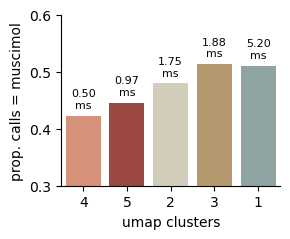

In [27]:
fig, ax = plt.subplots(figsize=(3,2.5))
sns.barplot(cluster_mean_dur, x='k_labels_order', y='prop_muscimol',
            hue='k_labels', palette=cluster_map,
            ax=ax
            )
means_in_order = cluster_mean_dur.sort_values('k_labels',ascending=True)['mean']
for bar, val in zip(ax.patches, means_in_order):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,  # adjust vertical position as needed
        f'{val*1000:.2f}\nms',
        ha='center', va='bottom', fontsize=8
    )

labels_in_order = cluster_mean_dur.sort_values('k_labels_order').index
ax.set_xticks(range(len(labels_in_order)))
ax.set_xticklabels(labels_in_order)
ax.set_xlabel('umap clusters')

ax.set_ylabel('prop. calls = muscimol')
ax.set_ylim(0.3,0.6)
ax.set_yticks([0.3,0.4,0.5,0.6])
ax.spines[['right','top']].set_visible(False)
ax.legend_.remove()
fig.tight_layout()
# fig.savefig(results_dir+'/combined/'+'counts_duration_cluster_propmuscimol'+manual_lab+'_samp.png',transparent=True, bbox_inches='tight')
for ext in ['png','pdf']:
    fig.savefig(results_dir+'/combined/'+'counts_duration_cluster_propmuscimol'+manual_lab+'.'+ext, 
                bbox_inches='tight', transparent=True, dpi=500)

##### Duration

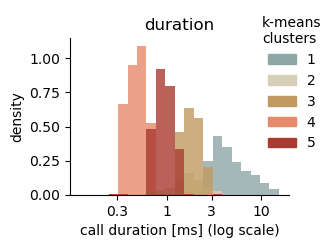

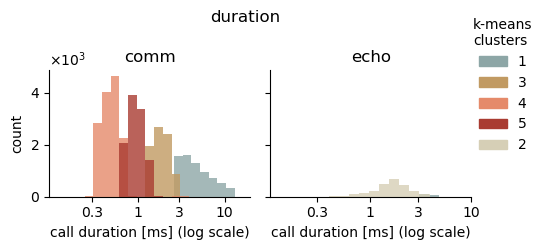

In [31]:
fig, ax = plot.hist_hue(df_analysis, x='duration', 
                        hue='k_labels', hue_palette=dict(zip(np.sort(df_analysis['k_labels'].unique()),cluster_map)),
                        alpha=0.8,
                        xlabel='call duration [ms]', scale=1000, # make ms
                        log=True, binsize=0.1, tick_vals=[0.3, 1, 3, 10],
                        title='duration', legend_title='k-means\nclusters', legend_bbox=(1.1,1),                        
                        # densities sum to 1 across all clusters
                        density=True, density_norm='all',
                        savedir=results_dir+'/combined', filename='call_dur_clusters_dnorm-allclust'+manual_lab+'.pdf' 
                        )
# if density = False
# ax.yaxis.set_major_formatter(formatter)
# fig.tight_layout()
# fig.savefig(results_dir + '/combined/call_dur_clusters_dnorm-count'+manual_lab+'_samp.png',
            # transparent=True, bbox_inches='tight')

fig, axes = plot.hist_hue(df_analysis, x='duration', 
                        hue='k_labels', hue_palette=dict(zip(np.sort(df_analysis['k_labels'].unique()),cluster_map)),
                        alpha=0.8,
                        xlabel='call duration [ms]', scale=1000, # make ms
                        log=True, binsize=0.1, tick_vals=[0.3, 1, 3, 10],
                        title='duration', legend_title='k-means\nclusters', legend_bbox=(1.1,1.0),                        
                        split_by='call_type', 
                        # counts = density needs to be False, otherwise proportions don't 
                        # come out right, whatever you do (would require more manips...)
                        density=False,                                             
                        )
axes[0].yaxis.set_major_formatter(formatter)
fig.tight_layout()
# fig.savefig(results_dir+'/combined/call_dur_clusters_count-clustcalltype'+manual_lab+'.png',
#             transparent=True, bbox_inches='tight')
for ext in ['png','pdf']:
    fig.savefig(results_dir+'/combined/call_dur_clusters_count-clustcalltype'+manual_lab+'.'+ext, 
                bbox_inches='tight', transparent=True, dpi=500)

##### Centroid, RMS

Note: I ran this with multiple versions: overall, by calltype, and previously by treatment too. 

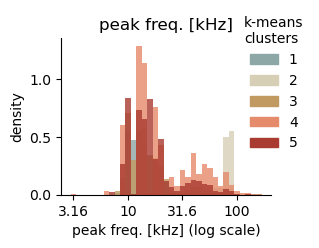

In [50]:
df = df_analysis
# metric = 'centroid_med'
metric = 'spec_peak'
bs = 0.05 # 0.04 for call type split
fig, ax = plot.hist_hue(df, x=metric, 
                        hue='k_labels', hue_palette=dict(zip(np.sort(df['k_labels'].unique()),cluster_map)),
                        alpha=0.8,
                        # split_by='call_type',
                        xlabel=metric_lab_map[metric], scale=1e-3, # make ms
                        # xlabel=metric_lab_map[metric]+'\n('+str(np.round(10**bs,2))+'kHz bins)', scale=1e-3, 

                        # log=False, binsize=1, # centroid
                        log=True, binsize=bs,
                        title=metric_lab_map[metric],#+' | '+sess, 
                        legend_title='k-means\nclusters', legend_bbox=(1.1,1),                        
                        # densities sum to 1 across all clusters
                        density=True, density_norm='all',
                        # density=False,
                        savedir=results_dir+'/combined', filename=metric+'_calltype_clusters_playback_dnorm-allclust'+manual_lab+'.pdf' 
                        )   
# axes[0].yaxis.set_major_formatter(formatter)
# fig.tight_layout()
# for ext in ['png','pdf']:
#     fig.savefig(results_dir+'/combined/'+metric+'_calltype_clusters_playback_dnorm-allclust'+manual_lab+'.'+ext, 
#                 bbox_inches='tight', transparent=True, dpi=500)
 

In [ ]:
   
metric = 'rms'
fig, ax = plot.hist_hue(df, x=metric, 
                        hue='k_labels', hue_palette=dict(zip(np.sort(df['k_labels'].unique()),cluster_map)),
                        alpha=0.8,
                        split_by='call_type',
                        xlabel=metric_lab_map[metric], scale=1e-3, # make ms
                        log=True, binsize=0.1, #tick_vals=[0.3, 1, 3, 10],
                        title=metric_lab_map[metric],#+' | '+sess, 
                        legend_title='k-means\nclusters', legend_bbox=(1.1,1),                        
                        # densities sum to 1 across all clusters
                        # density=True, density_norm='all',
                        density=False,
                        # savedir=results_dir+'/combined', filename=metric+'_calltype_clusters_playback_dnorm-allclust'+manual_lab+'.png' 
                        )                        

axes[0].yaxis.set_major_formatter(formatter)
fig.tight_layout()
for ext in ['png','pdf']:
    fig.savefig(results_dir+'/combined/'+metric+'_calltype_clusters_playback_dnorm-allclust'+manual_lab+'.'+ext, 
                bbox_inches='tight', transparent=True, dpi=500)


Duration bins are well-reflected in clusters, so given that muscimol has a pronounced
influence on duration, the number of calls in each cluster when stratified by treatment
and cluster will reflect this. 

Other parameters are more distributed, and project out from the center of the umap 
'radially', so aside from pronounced differences between the echolocation cluster (2) and
all others, not much difference. 

#### Call rates, counts and proportions

##### Playbacks

In [51]:
## for playback
# existing:
     # n_calls = computed based on number of trials in each call right after detection
     # ici = the same ^

play_dat = df_analysis.loc[df_analysis['condition']!='spontaneous']

n_trials_ea = 50

## trial
# compute number of calls per trial, within each recording

n_play_trials = (
play_dat
.groupby(['anim','sess_n','treatment','condition','rec_iter','trial_n'],observed=True)
.agg(n_calls_trial=('anim', 'size'),
     n_calls_orig_trial=('n_calls', lambda x: list(x.unique())[0]))
# could add call rate per trial if desired
.reset_index() 
)
# for each trial, get trial's trig start time in original rec, trial response length, and stim dur
n_play_trials, _ =  unpack.pull_data_from_recondat(n_play_trials)

## recording
# compute number of calls+rate of calling in each recording/collapse over trials

n_play_recs = (
n_play_trials
.groupby(['anim','sess_n','treatment','condition'],observed=True)
.agg(n_calls_rec=('n_calls_trial', 'sum'),
     n_calls_orig_rec=('n_calls_orig_trial', 'sum'),
     sum_trial_lens_rec=('seg_len_seconds','sum'))
.assign(rate_calls_rec_s=lambda df: df['n_calls_rec'] / df['sum_trial_lens_rec'])
.reset_index()
)

## session
# compute number of calls per session/collapse over recordings
n_play_sess = (
n_play_trials
.groupby(['anim','sess_n','treatment'],observed=True)
.agg(n_calls_sess=('n_calls_trial', 'sum'),
     n_calls_orig_sess=('n_calls_orig_trial', 'sum'),
     sum_trial_lens_sess=('seg_len_seconds','sum'))
.assign(rate_calls_sess_s=lambda df: df['n_calls_sess'] / df['sum_trial_lens_sess'])
.assign(sess_n_sort=[1,2,3,4, 2,1,4,3, 2,3,4, 2,1,4,3])
.reset_index()
)

## treatment
# # compute number of calls per treatment/collapse over sessions
# (
# n_play_trials
# .groupby(['anim','treatment'],observed=True)
# .agg(n_calls_treat=('n_calls_trial', 'sum'), # can easily be summed by seaborn...
#      n_calls_orig_treat=('n_calls_orig_trial', 'sum'))     
# # rate calls treat perhaps better to compute as average of sessions or rec rate
# .reset_index()
# )

# n_play_trials, n_play_recs, n_play_sess

## session - response rate
# compute proportion of trials at least 1 response, at level of session
p_trialresp_recs = (play_dat
.groupby(['anim','sess_n','treatment','condition'],observed=True)
.agg(n_trials_resp_rec = ('trial_n', lambda x: len(x.unique())),
     p_trials_resp_rec = ('trial_n', lambda x: len(x.unique())/(n_trials_ea)))
# sort: let 1 = first saline, 2 = first muscimol, 3 = second saline, 4 = second muscimol
# .assign(sess_n_sort=[1,2,3,4, 2,1,4,3, 2,3,4, 2,1,4,3])
.reset_index()
)

p_trialresp_sess = (play_dat
.groupby(['anim','sess_n','treatment'],observed=True)
.agg(n_trials_resp_sess = ('trial_n', lambda x: len(x.unique())),
     p_trials_resp_sess = ('trial_n', lambda x: len(x.unique())/(n_trials_ea*3))) # pooled over 3 
# sort: let 1 = first saline, 2 = first muscimol, 3 = second saline, 4 = second muscimol
.assign(sess_n_sort=[1,2,3,4, 2,1,4,3, 2,3,4, 2,1,4,3])
.reset_index()
)
## treatment - response rate
p_trialresp_treat = (
p_trialresp_sess
.groupby(['anim','treatment'],observed=True)
.agg(n_trials_resp_treat = ('n_trials_resp_sess', lambda x: np.sum(x)), 
     n_treat_sesss = ('sess_n', lambda x: len(x.unique()))) # number of sessions
.assign(p_trials_resp_treat = (lambda df: df['n_trials_resp_treat'] / (n_trials_ea*2*df['n_treat_sesss']))) # n trials x 3 x 2 or 1 
.reset_index()
)

# used:
# p_trialresp_sess, p_trialresp_treat
# n_play_recs, n_play_sess

###### Prop trials with responses (sessions)

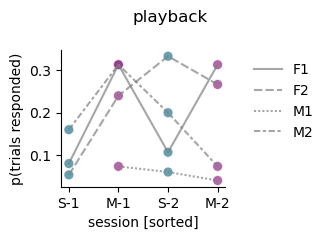

In [52]:
fig, axes = plot.line_scatter_sess(p_trialresp_sess, y='p_trials_resp_sess',
                hue_palette=treatment_map, ylabel='p(trials responded)', 
                suptitle='playback', reg=False,
                savedir=results_dir+'/playback', filename='prop_resp_sess'+manual_lab+'.png',
                )

###### Prop trials with responses (treatment)

/mnt/hpc/projects/BWFAFdeactivNpx/code/2_analysis/acoustic/../../npxtoolbox/plot.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/mnt/hpc/projects/BWFAFdeactivNpx/code/2_analysis/acoustic/../../npxtoolbox/plot.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


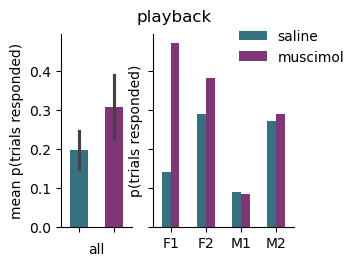

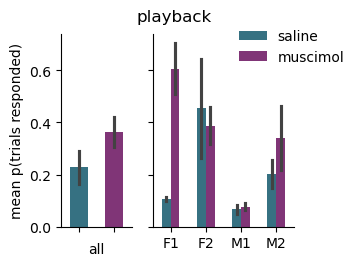

In [54]:


fig, axes = plot.bar_treat_anim(p_trialresp_treat, y='p_trials_resp_treat',
               hue_palette=treatment_map, ylabel='p(trials responded)',               
               wspace=0.2,
               legend_bbox=(1.11,0.95), suptitle='playback',               
               )
axes[1].set_ylabel('p(trials responded)')
axes[1].yaxis.label.set_visible(True)
fig.savefig(results_dir + '/playback/prop_resp_treat'+manual_lab+'_samp.png',transparent=True, bbox_inches='tight', dpi=500)

fig, axes = plot.bar_treat_anim(p_trialresp_recs, y='p_trials_resp_rec',
               hue_palette=treatment_map, ylabel='p(trials responded)',               
               wspace=0.2,
               legend_bbox=(1.11,0.95), suptitle='playback',               
               )

###### Call rate (treatment)

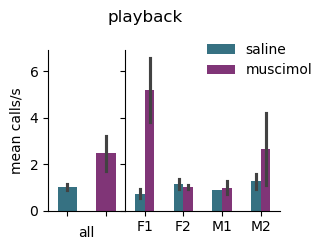

In [72]:
fig, axes = plot.bar_treat_anim(n_play_sess, y='rate_calls_sess_s',
               hue_palette=treatment_map, ylabel='calls/s',
               wspace=0,               
               legend_bbox=(1.1,0.9), suptitle='playback',               
               savedir=results_dir+'/playback', filename='call_rate_treat'+manual_lab+'.png'
               )

###### Call rate (recording)
Points are call rates computed by recording (condition) in each session. Showimg
rates for all sessions. 

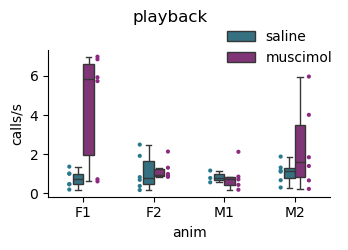

In [73]:
fig, axes = plot.strip_box_anim(n_play_recs, x='anim', y='rate_calls_rec_s',
                    hue_palette=treatment_map, ylabel='calls/s',
                    suptitle='playback', legend_bbox=(1.0,0.95),
                    savedir=results_dir+'/playback', filename='call_rate_recs'+manual_lab+'.png'
                    )

###### Call rate (sessions)

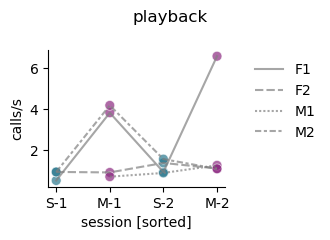

In [74]:
# call rate in each session

fig, axes = plot.line_scatter_sess(n_play_sess, y='rate_calls_sess_s',
                hue_palette=treatment_map, ylabel='calls/s', reg=False,
                suptitle='playback', #legend_bbox=(1.0,0.95),
                savedir=results_dir+'/playback', filename='call_rate_sess'+manual_lab+'.png',
                )            

##### Spontaneous

In [75]:
## spontaneous
spont_dat = df_analysis.loc[df_analysis['condition']=='spontaneous']

## recording 
# number and rate of calls per 15 min chunks
n_spont_rec = (
spont_dat   
.groupby(['anim','sess_n','treatment','rec_n','rec_iter'],observed=True) 
.agg(n_calls_rec=('anim', 'size'), 
    n_calls_orig_rec=('n_calls', lambda x: list(x.unique())[0]), 
    rec_dur=('rec_dur', lambda x: list(x.unique())[0]))
.assign(rate_calls_rec_s=lambda df: df['n_calls_rec'] / df['rec_dur'])
.reset_index()
)
# n_spont_rec['rate_calls_rec'] = n_spont_rec['n_calls_rec']/n_spont_rec['rec_dur']

## isolate first 15 mins of each session
# v1:
# n_spont_rec.sort_values(['anim','sess_n','treatment']).groupby(['anim','sess_n','treatment']).first()
    # F1/2_muscimol/rec1-1 is short, 70s
    # for M2/1_muscimol/rec1 had 2 calls, seemingly filtered out, so it picks out rec2

# v2:
# n_spont_first_15 = n_spont_rec.loc[(n_spont_rec['rec_dur']==900) & (n_spont_rec['rec_n']=='rec1')].sort_values(['anim','sess_n','treatment'])
    # this version gets the F1/2_muscimol/rec1-2
    # forces nothing for M2/1_muscimol/rec1 empty

## session
# compute number and rate of calls per session/collapse over recordings
n_spont_sess = (   
n_spont_rec
.groupby(['anim','sess_n','treatment'],observed=True)
.agg(n_calls_sess=('n_calls_rec', 'sum'),
     n_calls_orig_sess=('n_calls_orig_rec', 'sum'),
     rec_dur_cum=('rec_dur','sum'))
.assign(rate_calls_sess_s=lambda df: df['n_calls_sess'] / df['rec_dur_cum'])
.assign(sess_n_sort=[1,2,3,4, 2,1,4,3, 1,2,3,4, 2,1,4,3])
.reset_index()
)

# used
# n_spont_rec, n_spont_sess


###### Call rate (treatment)

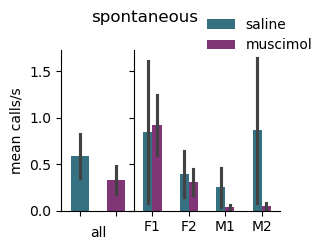

In [76]:
fig, _ = plot.bar_treat_anim(n_spont_sess, y='rate_calls_sess_s',
               hue_palette=treatment_map, ylabel='calls/s',
               wspace=0,
               legend_bbox=(1.1,1), suptitle='spontaneous',               
               savedir=results_dir+'/spontaneous', filename='call_rate_treat'+manual_lab+'.png'
               )

###### Call count (treatment)

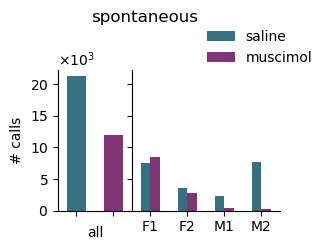

In [85]:

fig, axes = plot.bar_treat_anim(n_spont_sess, y='n_calls_sess',
               hue_palette=treatment_map, ylabel='# calls',
               estimator=sum,errorbar=None,
               wspace=0, legend_bbox=(1.1,0.95), suptitle='spontaneous',               
            #    savedir=results_dir+'/spontaneous', filename='n_calls_treat'+manual_lab+'_samp.png'
               )
axes[1].yaxis.set_major_formatter(formatter)
fig.tight_layout()
fig.savefig(results_dir + '/spontaneous/n_calls_treat'+manual_lab+'.png',
            transparent=True, bbox_inches='tight', dpi=500)

###### Call rate (recording)

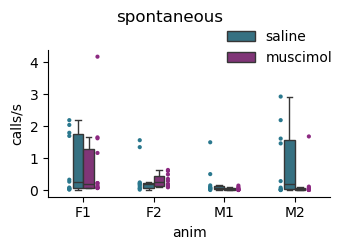

In [78]:
fig, axes = plot.strip_box_anim(n_spont_rec, x='anim', y='rate_calls_rec_s',
                    hue_palette=treatment_map, ylabel='calls/s',
                    suptitle='spontaneous', legend_bbox=(1.0,0.95),
                    savedir=results_dir+'/spontaneous', filename='call_rate_recs'+manual_lab+'.png'
                    )

###### Call rate (sessions)

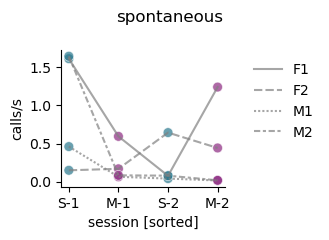

In [79]:
# call rate in each session
fig, axes = plot.line_scatter_sess(n_spont_sess, y='rate_calls_sess_s',
                hue_palette=treatment_map, ylabel='calls/s', reg=False,
                suptitle='spontaneous',
                savedir=results_dir+'/spontaneous', filename='call_rate_sess'+manual_lab+'.png',
                )

###### Call count (sessions)

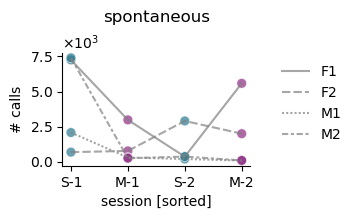

In [84]:
fig, ax = plot.line_scatter_sess(n_spont_sess, y='n_calls_sess',
                hue_palette=treatment_map, ylabel='# calls', reg=False,
               savedir=results_dir+'/spontaneous', filename='n_calls_sess'+manual_lab+'.png'
               )
ax.yaxis.set_major_formatter(formatter)
ax.set_title('spontaneous',y=1.2)
fig.tight_layout()
fig.savefig(results_dir + '/spontaneous/n_calls_sess'+manual_lab+'.png',
            transparent=True, bbox_inches='tight', dpi=500)

#### Ratio Playback - Spontaneous & Preferred Plots

In [81]:
# has no straightforward equivalent
# p_trialresp_sess, p_trialresp_treat

# there's no trial for spontaneous; recs also don't match (3 short vs 5 long); use sess values
# n_play_trials, n_play_recs, n_play_sess
#                n_spont_rec, n_spont_sess

# this here is important bc there is a missing value for M1/1 and subtraction of dfs will happen based on index
n_spontplay_sess = n_spont_sess.loc[~((n_spont_sess['anim']=='M1') & (n_spont_sess['sess_n']==1))].copy().reset_index(drop=True) 

n_spontplay_sess['ratio_rate_calls_pl_over_sp'] = (n_play_sess['rate_calls_sess_s']-n_spontplay_sess['rate_calls_sess_s'])/np.sum(n_play_sess['rate_calls_sess_s']-n_spontplay_sess['rate_calls_sess_s'])
n_spontplay_sess

,anim,sess_n,treatment,n_calls_sess,n_calls_orig_sess,rec_dur_cum,rate_calls_sess_s,sess_n_sort,ratio_rate_calls_pl_over_sp
0,F1,1,saline,7255,9228,4500.000000,1.612222,1,-0.053998
1,F1,2,muscimol,2977,4057,5003.194667,0.595020,2,0.161257
2,F1,3,saline,356,519,4552.008000,0.078207,3,0.043089
3,F1,4,muscimol,5584,6997,4500.000000,1.240889,4,0.266390
4,F2,1,muscimol,765,1147,4500.000000,0.170000,2,0.037577
5,F2,2,saline,678,1010,4500.000000,0.150667,1,0.039713
6,F2,3,muscimol,1994,2512,4500.000000,0.443111,4,0.033481
7,F2,4,saline,2900,12320,4500.000000,0.644444,3,0.036920
8,M1,2,muscimol,295,413,4500.000000,0.065556,2,0.032424
9,M1,3,saline,189,267,4500.000000,0.042000,3,0.042705


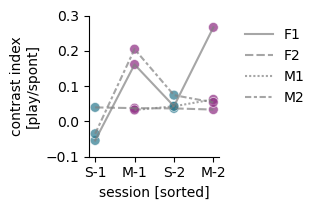

In [122]:
fig, ax = plot.line_scatter_sess(n_spontplay_sess, y='ratio_rate_calls_pl_over_sp',
               hue_palette=treatment_map, ylabel='contrast index\n[play/spont]', reg=False,
            #    title='playback/spontaneous', 
               figsize=(3.3,2.2), 
               # savedir=results_dir+'/combined', filename='ratio_callrate_sess'+manual_lab+'.png'
               )
ax.set_ylim(-0.1,0.3)
fig.tight_layout()
for ext in ['png','pdf']:
    fig.savefig(results_dir+'/combined/'+'ratio_callrate_sess'+manual_lab+'.'+ext, 
                bbox_inches='tight', transparent=True, dpi=500)
    


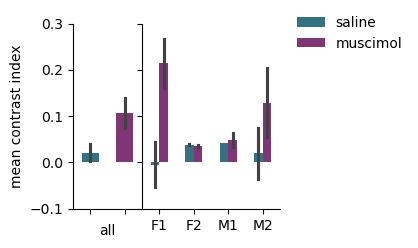

In [112]:
fig, ax = plot.bar_treat_anim(n_spontplay_sess, y='ratio_rate_calls_pl_over_sp',
               hue_palette=treatment_map, ylabel='contrast index',               
               wspace=0, legend_bbox=(1.4,1)
               )
ax[0].set_ylim(-0.1,0.3)
fig.tight_layout()
savedir=results_dir+'/combined';filename='ratio_callrate_treat'+manual_lab+'.png'
fig.savefig(savedir+'/'+filename,transparent=True,bbox_inches='tight', dpi=500)


/mnt/hpc/projects/BWFAFdeactivNpx/code/2_analysis/acoustic/../../npxtoolbox/plot.py:212: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend(loc='upper right', frameon=False, title=legend_title, **legend_kw)


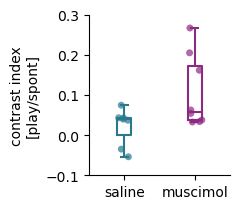

In [121]:
# sns.stripplot(n_spontplay_sess, x='treatment', y='ratio_rate_calls_pl_over_sp')
fig, ax = plot.strip_box(n_spontplay_sess, y='ratio_rate_calls_pl_over_sp',
                         hue_palette=treatment_map, ylabel='contrast index\n[play/spont]',
                         jitter=True, strip_size=5, #strip_alpha=0.7,
                         box_width=0.2, box_alpha=1,
                        #  suptitle='playback / spont.', 
                         legend_bbox=(1.0, 0.95), figsize=(2.5,2.2)
                         )
ax.set_ylim(-0.1,0.3)
# ax.set_title('playback / spont.')
fig.tight_layout()
for ext in ['png','pdf']:
    fig.savefig(results_dir+'/combined/'+'ratio_callrate_recs'+manual_lab+'.'+ext, 
                bbox_inches='tight', transparent=True, dpi=500)

/mnt/hpc/projects/BWFAFdeactivNpx/code/2_analysis/acoustic/../../npxtoolbox/plot.py:212: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend(loc='upper right', frameon=False, title=legend_title, **legend_kw)
/mnt/hpc/projects/BWFAFdeactivNpx/code/2_analysis/acoustic/../../npxtoolbox/plot.py:212: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend(loc='upper right', frameon=False, title=legend_title, **legend_kw)
/tmp/ipykernel_177154/2950583303.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


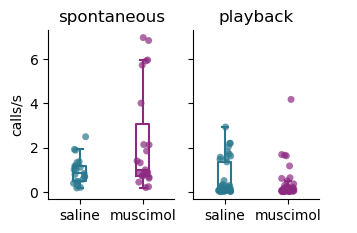

In [123]:
importlib.reload(plot)
fig, axes = plt.subplots(1,2, figsize=(3.5,2.2),
                         gridspec_kw={'wspace': 0.15},
                        sharey=True)
_, _ = plot.strip_box(n_spont_rec, y='rate_calls_rec_s',
                         hue_palette=treatment_map, ylabel='calls/s',
                         jitter=True, strip_size=5, 
                         box_width=0.2, box_alpha=1,
                        #  suptitle='spontaneous', 
                         legend_bbox=(1.0, 0.95), ax=axes[1]
                         )
_, _ =plot.strip_box(n_play_recs, y='rate_calls_rec_s',
                         hue_palette=treatment_map, ylabel='calls/s',
                         jitter=True, strip_size=5, 
                         box_width=0.2, box_alpha=1,
                        #  suptitle='playback', 
                         legend_bbox=(1.0, 0.95), ax=axes[0]
                         )
# _, _ = plot.strip_box(n_spontplay_sess, y='ratio_rate_calls_pl_over_sp',
#                          hue_palette=treatment_map, ylabel='ratio mean calls/s',
#                          jitter=True, strip_size=5, box_width=0.2, box_alpha=0.4,
#                          suptitle='playback / spont.', legend_bbox=(1.0, 0.95), ax=axes[2]
#                          )
axes[0].set_title('spontaneous')
axes[1].set_title('playback')
fig.tight_layout()
for ext in ['png','pdf']:
    fig.savefig(results_dir+'/combined/'+'callrate_recs'+manual_lab+'.'+ext, 
                bbox_inches='tight', transparent=True, dpi=500)

/mnt/hpc/projects/BWFAFdeactivNpx/code/2_analysis/acoustic/../../npxtoolbox/plot.py:212: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend(loc='upper right', frameon=False, title=legend_title, **legend_kw)


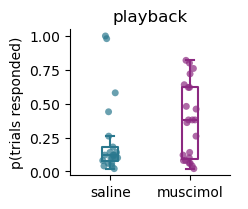

In [124]:

fig, ax = plot.strip_box(p_trialresp_recs, y='p_trials_resp_rec',
                         hue_palette=treatment_map, ylabel='p(trials responded)',
                         jitter=True, strip_size=5, 
                         box_width=0.2, box_alpha=1,
                         legend_bbox=(1.0, 0.95), figsize=(2.5,2.2)
                         )
ax.set_title('playback')
fig.tight_layout()
for ext in ['png','pdf']:
    fig.savefig(results_dir+'/playback/'+'prop_resp_rec'+manual_lab+'.'+ext, 
                bbox_inches='tight', transparent=True, dpi=500)

In [125]:
print(wrangle.group_summary(n_spont_rec, groupby=['treatment'], variables=['rate_calls_rec_s']))

print(wrangle.group_summary(n_play_recs, groupby=['treatment'], variables=['rate_calls_rec_s']))
print(wrangle.group_summary(p_trialresp_recs, groupby=['treatment'], variables=['p_trials_resp_rec']))    

print(wrangle.group_summary(n_spontplay_sess, groupby=['treatment'], variables=['ratio_rate_calls_pl_over_sp']))    



          rate_calls_rec_s                                    
                      mean    median       std       sem count
treatment                                                     
saline            0.577534  0.117778  0.819755  0.128024    41
muscimol          0.359731  0.091667  0.751488  0.115957    42
          rate_calls_rec_s                                    
                      mean    median       std       sem count
treatment                                                     
saline            0.948187  0.828074  0.605759  0.132187    21
muscimol          2.273612  0.991133  2.324960  0.484788    23
          p_trials_resp_rec                                 
                       mean median       std       sem count
treatment                                                   
saline             0.227619   0.12  0.286529  0.062526    21
muscimol           0.364348   0.38  0.275678  0.057483    23
          ratio_rate_calls_pl_over_sp                            

#### Call durations

Plot durations...
- in total / treatment
- by cluster / treatment
- by call type / treatment

In [129]:
wrangle.group_summary(df_analysis, groupby=['treatment'], variables=['duration'])

wrangle.group_summary(df_analysis, groupby=['sess_type', 'treatment'], variables=['duration'])

wrangle.group_summary(df_analysis, groupby=['sess_type','call_type','treatment'], variables=['duration'])


duration                                     
                                     mean    median       std       sem  count
sess_type   call_type treatment                                               
spontaneous comm      saline     0.001713  0.000914  0.002046  0.000014  19972
                      muscimol   0.001725  0.001039  0.001886  0.000018  11246
            echo      saline     0.001892  0.001706  0.000810  0.000023   1245
                      muscimol   0.002095  0.001997  0.000888  0.000032    776
playback    comm      saline     0.001049  0.000622  0.001461  0.000039   1369
                      muscimol   0.002066  0.001206  0.002282  0.000027   7165
            echo      saline     0.001165  0.001102  0.000497  0.000040    154
                      muscimol   0.001793  0.001706  0.000808  0.000036    496

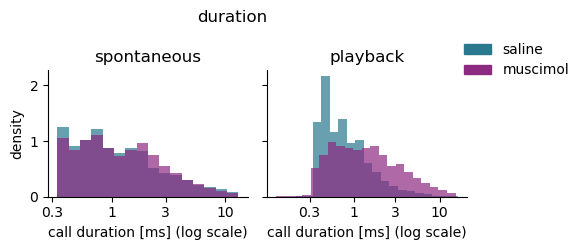

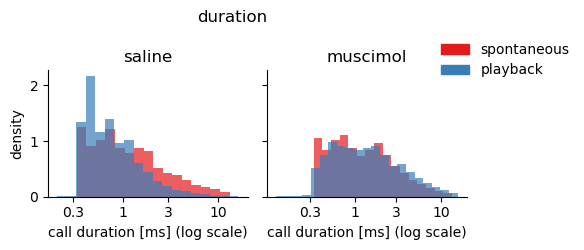

In [ ]:
importlib.reload(plot)
# spontaneous vs playback
fig, axes = plot.hist_hue(df_analysis, x='duration', 
                        hue_palette=treatment_map,
                        xlabel='call duration [ms]', scale=1000, # make ms
                        log=True, binsize=0.1, tick_vals=[0.3, 1, 3, 10],                        
                        split_by='sess_type', 
                        legend_bbox=(1.2,0.9),
                        title='duration',

                        # counts
                        # density=False, sharey=True
                    
                        # densities which sum to 1 for each treatment/sesstype 
                        density=True, sharey=True, 
                        savedir=results_dir+'/combined', filename='call_dur_sesstype_dnorm-treat'+manual_lab+'.pdf' 
                        # densities sum to 1 across treatments, for each sesstype
                        # density=True, sharey=True, density_norm='all', alpha=0.7,
                        # savedir=results_dir+'/combined', filename='call_dur_sesstype_dnorm-alltreat'+manual_lab+'_samp.png' 
                        )


##### Playback conditions

In [137]:
conditions_labels = dict(zip(['distress_seq','echo_seq','isolation_1'],['distress','echolocation','pup isolation']))

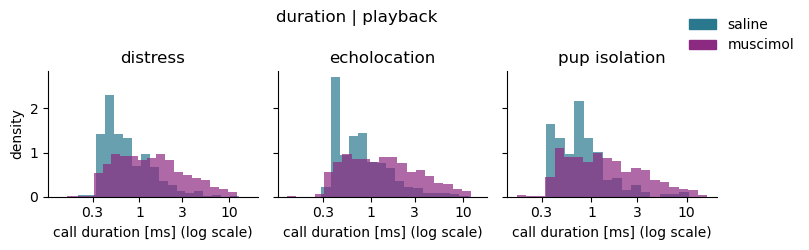

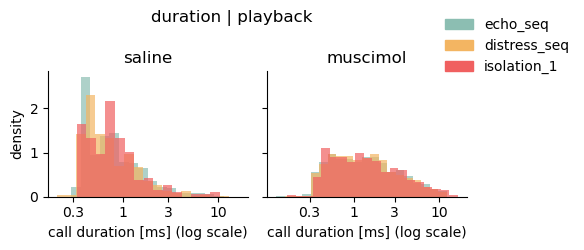

In [146]:
fig, ax = plot.hist_hue(df_analysis.loc[df_analysis['sess_type']=='playback'], x='duration', hue_palette=treatment_map,
                        xlabel='call duration [ms]', scale=1000, # make ms
                        log=True, binsize=0.1, tick_vals=[0.3, 1, 3, 10],
                        split_by='condition', split_labels=conditions_labels,    
                        title='duration | playback',
                        density=True, legend_bbox=(1.1,1),
                        # density False further helps emphasize that muscimol is longer, not just more sampling*                    
                        savedir=results_dir+'/playback', filename='call_dur_conditions_dnorm-treat'+manual_lab+'.pdf' 
                        )

fig, ax = plot.hist_hue(df_analysis.loc[df_analysis['sess_type']=='playback'], x='duration', 
                        hue='condition', hue_palette=conditions_map,
                        xlabel='call duration [ms]', scale=1000, # make ms
                        log=True, binsize=0.1, tick_vals=[0.3, 1, 3, 10],
                        split_by='treatment', legend_bbox=(1.2,1),
                        title='duration | playback',
                        savedir=results_dir+'/playback', filename='call_dur_treat_dnorm-conditions'+manual_lab+'.pdf' 
                        )

##### Call type

In [21]:
df_analysis.groupby(['sess_type','treatment','call_type']).count()

/tmp/ipykernel_1306690/3770044422.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_analysis.groupby(['sess_type','treatment','call_type']).count()


concat_index  index   anim   sess  sess_n  \
sess_type   treatment call_type                                              
playback    saline    comm               1369   1369   1369   1369    1369   
                      echo                154    154    154    154     154   
            muscimol  comm               7165   7165   7165   7165    7165   
                      echo                496    496    496    496     496   
spontaneous saline    comm              19972  19972  19972  19972   19972   
                      echo               1245   1245   1245   1245    1245   
            muscimol  comm              11246  11246  11246  11246   11246   
                      echo                776    776    776    776     776   

                                 condition  rec_n  rec_iter   name  \
sess_type   treatment call_type                                      
playback    saline    comm            1369      0      1369   1369   
                      echo             154      0       154    154   
            muscimol  comm            7165      0      7165   7165   
                      echo             496      0       496    496   
spontaneous saline    comm           19972  19972     19972  19972   
                      echo            1245   1245      1245   1245   
            muscimol  comm           11246  11246     11246  11246   
                      echo             776    776       776    776   

                                 start_seconds  ...  sampling  curated_sample  \
sess_type   treatment call_type                 ...                             
playback    saline    comm                1369  ...      1369            1369   
                      echo                 154  ...       154             154   
            muscimol  comm                7165  ...      7165            7165   
                      echo                 496  ...       496             496   
spontaneous saline    comm               19972  ...     19972           19972   
                      echo                1245  ...      1245            1245   
            muscimol  comm               11246  ...     11246           11246   
                      echo                 776  ...       776             776   

                                 duration_bin_ms  duration_bin  rms_bin  \
sess_type   treatment call_type                                           
playback    saline    comm                  1369          1369     1369   
                      echo                   154           154      154   
            muscimol  comm                  7165          7165     7165   
                      echo                   496           496      496   
spontaneous saline    comm                 19972         19972    19972   
                      echo                  1245          1245     1245   
            muscimol  comm                 11246         11246    11246   
                      echo                   776           776      776   

                                 spec_peak_bin  center_f_peak_bin  \
sess_type   treatment call_type                                     
playback    saline    comm                1369               1361   
                      echo                 154                154   
            muscimol  comm                7165               7123   
                      echo                 496                496   
spontaneous saline    comm               19972              19869   
                      echo                1245               1245   
            muscimol  comm               11246              11188   
                      echo                 776                776   

                                 f0_mean_bin  centroid_med_bin  auc_bin  
sess_type   treatment call_type                                          
playback    saline    comm              1238              1369     1361  
                      echo               154               154      154  
  

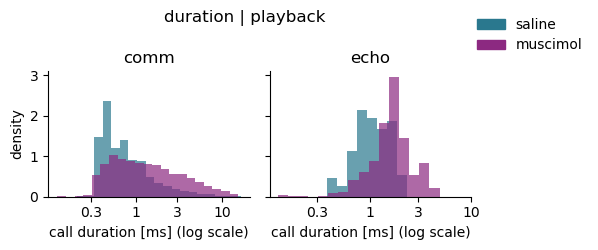

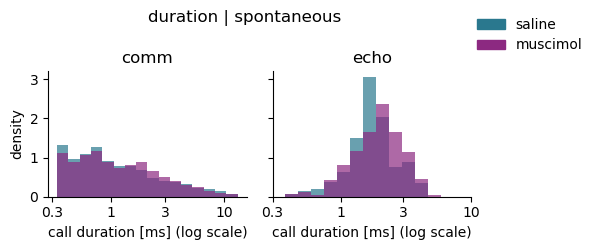

In [151]:
fig, ax = plot.hist_hue(df_analysis.loc[df_analysis['sess_type']=='playback'], x='duration', hue_palette=treatment_map,
                        xlabel='call duration [ms]', scale=1000, # make ms
                        log=True, binsize=0.1, tick_vals=[0.3, 1, 3, 10],
                        split_by='call_type',
                        title='duration | playback',
                        density=True, legend_bbox=(1.2,1),
                        savedir=results_dir+'/playback', filename='call_dur_calltype_dnorm-treat'+manual_lab+'.pdf' 
                        
                        )
fig, ax = plot.hist_hue(df_analysis.loc[df_analysis['sess_type']=='spontaneous'], x='duration', hue_palette=treatment_map,
                        xlabel='call duration [ms]', scale=1000, # make ms
                        log=True, binsize=0.1, tick_vals=[0.3, 1, 3, 10],
                        split_by='call_type',
                        title='duration | spontaneous', legend_bbox=(1.2,1),
                        savedir=results_dir+'/spontaneous', filename='call_dur_calltype_dnorm-treat'+manual_lab+'.pdf' 
                        )

#### Call spectra, spectral params

##### Playback, spontaneous

###### Central pitch

In [12]:
wrangle.group_summary(df_analysis, groupby=['sess_type', 'treatment'], variables=['centroid_med'])
wrangle.group_summary(df_analysis, groupby=['sess_type', 'treatment'], variables=['spec_peak'])

wrangle.group_summary(df_analysis, groupby=['sess_type','call_type','treatment'], variables=['centroid_med'])


centroid_med                              \
                                         mean        median           std   
sess_type   call_type treatment                                             
playback    comm      saline     57698.131699  56698.014774  10535.013319   
                      muscimol   66952.890548  68113.636685   8235.200250   
            echo      saline     80728.695582  80996.767208   1941.961691   
                      muscimol   80852.081903  81025.977939   2176.093859   
spontaneous comm      saline     65138.694543  65967.297734   8731.280769   
                      muscimol   66566.833153  67506.100500   8124.519886   
            echo      saline     80957.117087  81171.359367   1690.945174   
                      muscimol   80294.953882  80388.386293   2210.121134   

                                                    
                                        sem  count  
sess_type   call_type treatment                     
playback    comm      saline     284.730090   1369  
                      muscimol    97.289521   7165  
            echo      saline     156.487733    154  
                      muscimol    97.709499    496  
spontaneous comm      saline      61.782741  19972  
                      muscimol    76.612329  11246  
            echo      saline      47.923094   1245  
                      muscimol    79.338725    776

In [ ]:
# measures of central pitch
for metric in ['centroid_med']:
    bs=1; bs_ = bs
    # bs = 0.01; bs_ = np.round(10**bs,2)
    plot.hist_hue(df_analysis, x=metric, hue_palette=treatment_map,                        
            xlabel=metric_lab_map[metric]+'\n('+str(bs_)+'kHz bins)', scale=1e-3, 
            binsize=bs,                         
            log=False, 
            split_by='sess_type', title=metric_lab_map[metric],
            legend_bbox=(1.2,1),                        
            density=True, density_norm='hue',
            savedir=results_dir+'/combined', filename=metric+'_dnorm-treat'+manual_lab+'.png' 
            )
for metric in ['spec_peak']:
    # bs=5; bs_ = bs
    bs = 0.05; bs_ = np.round(10**bs,2)
    plot.hist_hue(df_analysis, x=metric, hue_palette=treatment_map,                        
            xlabel=metric_lab_map[metric]+'\n('+str(bs_)+'kHz bins)', scale=1e-3, 
            binsize=bs,                         
            log=True, 
            split_by='sess_type', title=metric_lab_map[metric],
            legend_bbox=(1.2,1),                        
            density=True, density_norm='hue',
            savedir=results_dir+'/combined', filename=metric+'_dnorm-treat'+manual_lab+'.png' 
            )

- Centroid varies by muscimol only within playback

###### Energy

In [8]:
rms_df1 = wrangle.group_summary(df_analysis, groupby=['sess_type', 'treatment'], variables=['rms'])
np.log10(rms_df1)
rms_df2 = wrangle.group_summary(df_analysis, groupby=['sess_type', 'call_type','treatment'], variables=['rms'])
np.log10(rms_df2)

rms                                \
                                     mean    median       std       sem   
sess_type   call_type treatment                                           
spontaneous comm      saline     3.026381  1.327871  4.260624  2.110413   
                      muscimol   2.822395  1.251724  3.988295  1.962796   
            echo      saline     5.369888  5.166457  5.473925  3.926340   
                      muscimol   5.577157  5.310261  5.676502  4.231571   
playback    comm      saline     2.864070  1.970728  3.446848  1.878646   
                      muscimol   2.442082  1.109098  3.431718  1.504110   
            echo      saline     5.256030  4.785856  5.426731  4.332971   
                      muscimol   5.509160  5.112964  5.673492  4.325751   

                                           
                                    count  
sess_type   call_type treatment            
spontaneous comm      saline     4.300422  
                      muscimol   4.050998  
            echo      saline     3.095169  
                      muscimol   2.889862  
playback    comm      saline     3.136403  
                      muscimol   3.855216  
            echo      saline     2.187521  
                      muscimol   2.695482

In [ ]:
# measures of energy
for metric in ['rms']:
    plot.hist_hue(df_analysis, x=metric, hue_palette=treatment_map,                        
            xlabel='norm. '+metric+' [$V^{2}$]\n', scale=1e-3,           
            log=True, binsize=0.1, 
            split_by='sess_type', title=metric_lab_map[metric],
            legend_bbox=(1.2,1),                        
            density=True, density_norm='hue',
            savedir=results_dir+'/combined', filename=metric+'_dnorm-treat'+manual_lab+'.png' 
            )

- RMS and AUC appear to vary between muscimol only within playback

##### Call type

playback


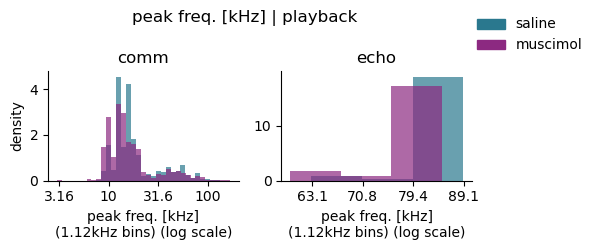

In [176]:
sess = 'playback'
print(sess)
df = df_analysis.loc[df_analysis['sess_type']==sess]
fitsamp = '' 
for metric in ['spec_peak']:
    bs = 0.05; bs_ = np.round(10**bs,2) # comm
    # bs = 0.01; bs_ = np.round(10**bs,2) # echo
    plot.hist_hue(df, x=metric, hue_palette=treatment_map,                        
            xlabel=metric_lab_map[metric]+'\n('+str(bs_)+'kHz bins)', scale=1e-3, 
            binsize=bs,                         
            log=True,                        
            split_by='call_type', title=metric_lab_map[metric] + ' | ' + sess, sharey=False,
            legend_bbox=(1.2,1),                        
            density=True, density_norm='hue',
            savedir=results_dir+'/'+sess, filename=metric+'_dnorm-treat'+manual_lab+fitsamp+'_scalecomm.pdf' 
            )

In [ ]:
# for sess in df_analysis['sess_type'].unique():
sess = 'playback'
print(sess)
df = df_analysis.loc[df_analysis['sess_type']==sess]
fitsamp = '' 

for metric in ['centroid_med']:
    bs=1; bs_ = bs
    # bs = 0.01; bs_ = np.round(10**bs,2)
    plot.hist_hue(df, x=metric, hue_palette=treatment_map,                        
            xlabel=metric_lab_map[metric]+'\n('+str(bs_)+'kHz bins)', scale=1e-3, 
            binsize=bs,                         
            log=False,                     
            split_by='call_type', title=metric_lab_map[metric] + ' | ' + sess,
            legend_bbox=(1.2,1),                        
            density=True, density_norm='hue',
            savedir=results_dir+'/'+sess, filename=metric+'_dnorm-treat'+manual_lab+fitsamp+'.pdf' 
            )
for metric in ['spec_peak']:
    bs = 0.03; bs_ = np.round(10**bs,2)
    plot.hist_hue(df, x=metric, hue_palette=treatment_map,                        
            xlabel=metric_lab_map[metric]+'\n('+str(bs_)+'kHz bins)', scale=1e-3, 
            binsize=bs,                         
            log=True,                        
            split_by='call_type', title=metric_lab_map[metric] + ' | ' + sess,
            legend_bbox=(1.2,1),                        
            density=True, density_norm='hue',
            savedir=results_dir+'/'+sess, filename=metric+'_dnorm-treat'+manual_lab+fitsamp+'.pdf' 
            )
# measures of energy
for metric in ['rms']:
    plot.hist_hue(df, x=metric, hue_palette=treatment_map,                        
            xlabel='norm. '+metric+' [$V^{2}$]\n', scale=1e-3,           
            log=True, binsize=0.1, 
            split_by='call_type', title=metric_lab_map[metric] + ' | ' + sess,
            legend_bbox=(1.2,1),                        
            density=True, density_norm='hue',
            savedir=results_dir+'/'+sess, filename=metric+'_dnorm-treat'+manual_lab+fitsamp+'.pdf' 
            )
